In [2]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
from sklearn import neural_network
from sklearn.metrics import confusion_matrix

from database import create_dataset
from utils import eval_multi_class, plot_confusion_matrix, split_data

#### Pas 1 - Crearea dataset-ului si impartirea acestuia in seturi de antrenament si validare

In [3]:
original_images, sepia_images, outputs_names = create_dataset()
train_inputs, train_outputs, validation_inputs, validation_outputs = split_data(original_images, sepia_images)

### Pas 2 - Antrenarea modelului MLPClassifier din scikit-learn

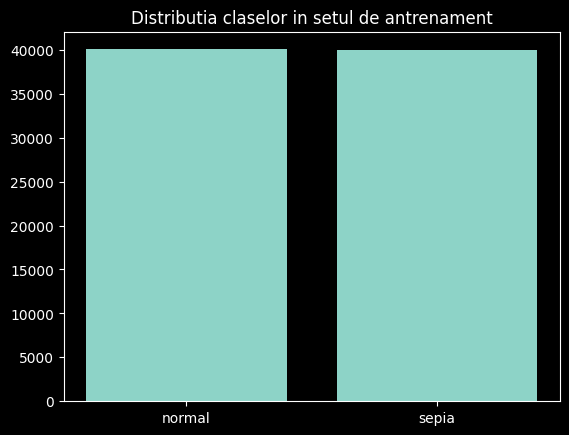

In [4]:
bins = range(len(outputs_names) + 1)
plt.hist(train_outputs, bins, rwidth=0.8)
bin_w = (max(bins) - min(bins)) / (len(bins) - 1)
plt.xticks(np.arange(min(bins) + bin_w / 2, max(bins), bin_w), outputs_names)
plt.title('Distributia claselor in setul de antrenament')
plt.show()

### Pas 3 - Evaluarea modelului MLPClassifier

In [5]:
print(f"Train examples: {len(train_inputs)}, Validation examples: {len(validation_inputs)}")
classifier = neural_network.MLPClassifier(
    hidden_layer_sizes=(100,),  # Un singur strat ascuns cu 100 de neuroni
    activation='relu',          # Funcția de activare ReLU
    max_iter=200,              # Numărul maxim de iterații pentru antrenare
    solver='sgd',              # Algoritmul de optimizare Stochastic Gradient Descent
    random_state=1,       # Setam o stare aleatoare pentru reproducibilitate
    learning_rate_init=0.1  # Rata de învățare inițială
)
classifier.fit(train_inputs, train_outputs)
print("Modelul a fost antrenat.")

/Users/razvandusa/PycharmProjects/AILab7/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


### Pas 4 - Evaluarea modelului MLPClassifier

In [ ]:
computed_outputs = classifier.predict(validation_inputs)

acc, prec, recall, cm = eval_multi_class(np.array(validation_outputs), computed_outputs, outputs_names)

plot_confusion_matrix(cm, outputs_names, "normal vs sepia")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", recall)


### Pas 5 - Experimentarea cu diferite configuratii ale modelului MLPClassifier

In [ ]:
configs = [
    {"hidden_layer_sizes": (10,), "max_iter": 100, "learning_rate_init": 0.1},
    {"hidden_layer_sizes": (100,), "max_iter": 100, "learning_rate_init": 0.1},
    {"hidden_layer_sizes": (100, 50), "max_iter": 100, "learning_rate_init": 0.1}, # 2 straturi ascunse, primul cu 100 de neuroni, al doilea cu 50 de neuroni
    {"hidden_layer_sizes": (100,), "max_iter": 200, "learning_rate_init": 0.1},
    {"hidden_layer_sizes": (100,), "max_iter": 100, "learning_rate_init": 0.01},
    {"hidden_layer_sizes": (100,), "max_iter": 100, "learning_rate_init": 0.5},
]

results = []
for cfg in configs:
    classifier = neural_network.MLPClassifier(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        activation='relu',
        max_iter=cfg["max_iter"],
        solver='sgd',
        random_state=1,
        learning_rate_init=cfg["learning_rate_init"]
    )
    classifier.fit(train_inputs, train_outputs)
    computed_outputs = classifier.predict(validation_inputs)
    acc, _, _, _ = eval_multi_class(np.array(validation_outputs), computed_outputs, outputs_names)
    results.append((cfg, acc))
    print(f"HL={cfg['hidden_layer_sizes']}, iter={cfg['max_iter']}, lr={cfg['learning_rate_init']} => acc={acc:.4f}")